# Train — ResNet-18

Trains and evaluates ResNet-18 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet18"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1752 | Val: 495 | Test: 280


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet18"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-18: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders, same as every other architecture
# here -- its own (capped) batch size and image size, per cfg.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-18: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model (Transfer Learning with ResNet-18)

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-18)
# ---------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the tuned step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-18] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-18] Epoch   1/100 | LR: 3.88e-04 | train loss 0.9448 acc 0.580 | val loss 0.5818 acc 0.766 *


[ResNet-18] Epoch   2/100 | LR: 3.88e-04 | train loss 0.6208 acc 0.704 | val loss 0.7629 acc 0.721


[ResNet-18] Epoch   3/100 | LR: 3.88e-04 | train loss 0.5874 acc 0.731 | val loss 0.7798 acc 0.707


[ResNet-18] Epoch   4/100 | LR: 3.88e-04 | train loss 0.5452 acc 0.761 | val loss 0.5812 acc 0.780 *


...

[ResNet-18] Epoch  21/100 | LR: 3.88e-05 | train loss 0.1108 acc 0.947 | val loss 0.4663 acc 0.863


[ResNet-18] Epoch  22/100 | LR: 3.88e-05 | train loss 0.0855 acc 0.960 | val loss 0.5002 acc 0.859


[ResNet-18] Epoch  23/100 | LR: 3.88e-05 | train loss 0.0968 acc 0.952 | val loss 0.4854 acc 0.865


[ResNet-18] Epoch  24/100 | LR: 3.88e-06 | train loss 0.0913 acc 0.955 | val loss 0.5275 acc 0.851


[ResNet-18] Epoch  25/100 | LR: 3.88e-06 | train loss 0.1008 acc 0.948 | val loss 0.5300 acc 0.851

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 25.

[ResNet-18] Restored best checkpoint (val loss = 0.4267)


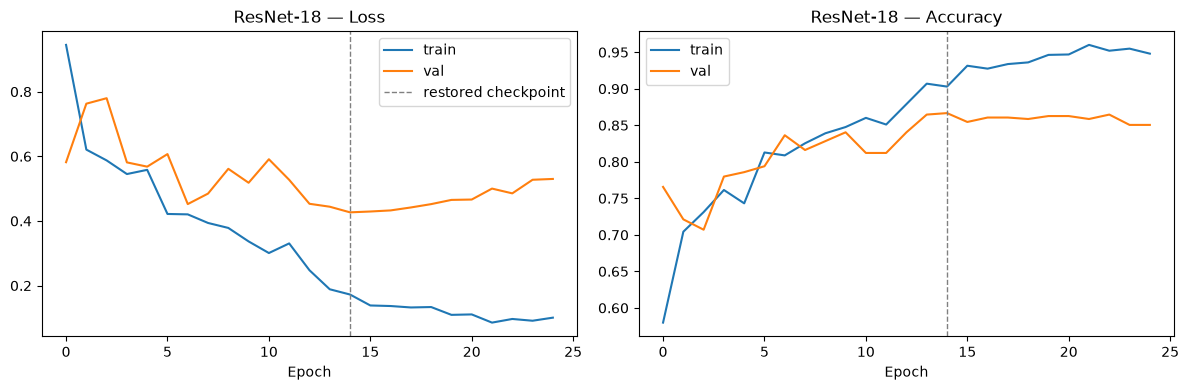

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.854


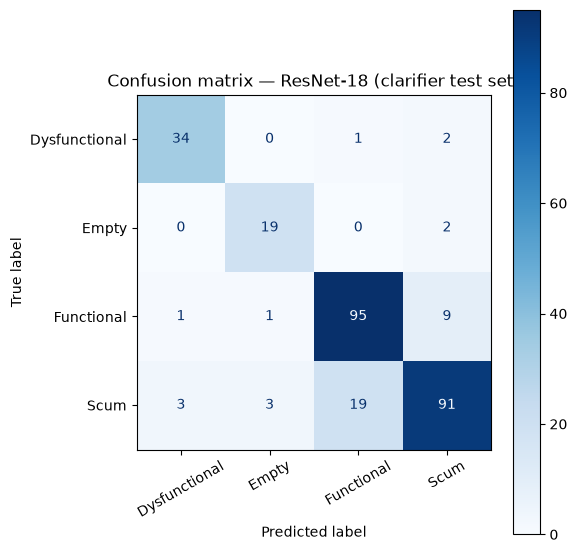

               precision    recall  f1-score   support

Dysfunctional      0.895     0.919     0.907        37
        Empty      0.826     0.905     0.864        21
   Functional      0.826     0.896     0.860       106
         Scum      0.875     0.784     0.827       116

     accuracy                          0.854       280
    macro avg      0.855     0.876     0.864       280
 weighted avg      0.855     0.854     0.853       280



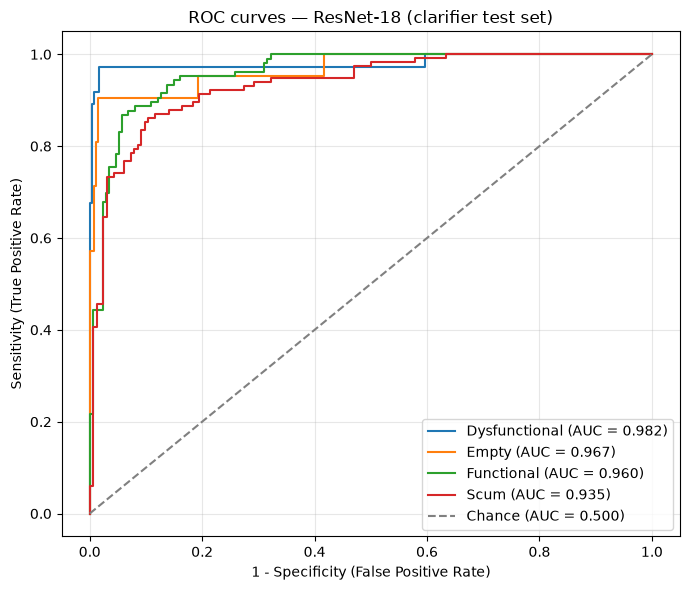

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.982
  Empty          : 0.967
  Functional     : 0.960
  Scum           : 0.935

Mean AUC (over 4/4 classes with test examples): 0.961


(np.float64(0.8535714285714285),
 {'Dysfunctional': 0.9818707596485374,
  'Empty': 0.9672733958448243,
  'Functional': 0.9602580785079158,
  'Scum': 0.9346614802354921})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-18", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [6]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/clarifier_aug/results_clarifier_resnet18_stratified.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
